In [31]:
import time

# Flights: (FlightID, Start, End)
flights = [
    ('F1', 9, 11),
    ('F2', 10, 12),
    ('F3', 12, 14),
    ('F4', 13, 15)
]

crew_members = ['C1', 'C2', 'C3']

# Check constraints
def is_valid(assignment, crew, flight):
    for f, c in assignment.items():
        if c == crew:
            # check overlap
            if not (flight[2] <= f[1] or flight[1] >= f[2]):
                return False
    return True

# Backtracking function
def assign_flights(assignment, flights):
    if len(assignment) == len(flights):
        return assignment

    for flight in flights:
        if flight not in assignment:
            for crew in crew_members:
                if is_valid(assignment, crew, flight):
                    assignment[flight] = crew
                    result = assign_flights(assignment, flights)
                    if result:
                        return result
                    del assignment[flight]
            return None

# Run
result = assign_flights({}, flights)
print("Final Assignment:", result)

Final Assignment: {('F1', 9, 11): 'C1', ('F2', 10, 12): 'C2', ('F3', 12, 14): 'C1', ('F4', 13, 15): 'C2'}


In [ ]:
task 2 Branch and Bound

In [5]:
import time

# Sample data
flights = [
    ("F1", 9, 11),
    ("F2", 10, 12),
    ("F3", 12, 14),
    ("F4", 13, 15)
]

crew_members = ["C1", "C2", "C3"]

# Check overlapping constraint
def is_valid(assignment, crew, flight):
    for fid, c in assignment.items():
        if c == crew:
            for f in flights:
                if f[0] == fid:
                    if not (flight[2] <= f[1] or flight[1] >= f[2]):
                        return False
    return True


def crew_workload(assignment):
    workload = {}
    flight_map = {f[0]: f for f in flights}

    for fid, crew in assignment.items():
        _, s, e = flight_map[fid]
        workload[crew] = workload.get(crew, 0) + (e - s)

    return max(workload.values()) if workload else 0


def branch_and_bound(flights, crew_members):
    best_result = None
    best_cost = float('inf')

    def solve(index, assignment):
        nonlocal best_result, best_cost

        if index == len(flights):
            cost = crew_workload(assignment)
            if cost < best_cost:
                best_cost = cost
                best_result = assignment.copy()
            return

        # Bounding
        if crew_workload(assignment) >= best_cost:
            return

        flight = flights[index]

        for crew in crew_members:
            if is_valid(assignment, crew, flight):
                assignment[flight[0]] = crew
                solve(index + 1, assignment)
                del assignment[flight[0]]

    solve(0, {})
    return best_result, best_cost


# Run
start = time.time()
result, cost = branch_and_bound(flights, crew_members)
end = time.time()

print("\n=== Branch and Bound Result ===")
if result:
    for f, c in result.items():
        print(f"{f} → {c}")
    print(f"\nOptimal Max Workload: {cost} hours")
else:
    print("No valid solution")

print(f"Time: {(end - start)*1000:.4f} ms")


=== Branch and Bound Result ===
F1 → C1
F2 → C2
F3 → C1
F4 → C2

Optimal Max Workload: 4 hours
Time: 0.9990 ms


In [ ]:
Task 3 

In [7]:
# ── Algorithm 1: Naive String Matching ──

def naive_search(text, pattern):
    """
    Brute-force: slide pattern over text one character at a time.
    Time complexity: O(n * m)
    """
    n, m = len(text), len(pattern)
    comparisons = 0
    matches = []

    for i in range(n - m + 1):           # slide window
        match = True
        for j in range(m):               # compare each character
            comparisons += 1
            if text[i + j] != pattern[j]:
                match = False
                break
        if match:
            matches.append(i)

    return matches, comparisons

print("Naive search defined.")

Naive search defined.


In [9]:
# ── Algorithm 2: KMP String Matching ──

def build_lps(pattern):
    """
    Build Longest Proper Prefix which is also Suffix (LPS) array.
    This helps KMP skip redundant comparisons.
    """
    m   = len(pattern)
    lps = [0] * m
    length = 0
    i = 1

    while i < m:
        if pattern[i] == pattern[length]:
            length += 1
            lps[i]  = length
            i += 1
        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1
    return lps


def kmp_search(text, pattern):
    """
    KMP Algorithm: uses LPS array to avoid rechecking characters.
    Time complexity: O(n + m)
    """
    n, m = len(text), len(pattern)
    lps  = build_lps(pattern)
    comparisons = 0
    matches = []
    i = j = 0

    while i < n:
        comparisons += 1
        if text[i] == pattern[j]:
            i += 1
            j += 1
        if j == m:
            matches.append(i - j)
            j = lps[j - 1]
        elif i < n and text[i] != pattern[j]:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return matches, comparisons

print("KMP search defined.")

KMP search defined.


In [11]:
# ── Algorithm 3: Rabin-Karp String Matching ──

def rabin_karp_search(text, pattern, base=256, mod=101):
    """
    Rabin-Karp: uses rolling hash to find matches quickly.
    Time complexity: O(n + m) average, O(nm) worst case.
    """
    n, m = len(text), len(pattern)
    comparisons = 0
    matches = []

    h      = pow(base, m - 1, mod)    # base^(m-1) mod mod
    p_hash = 0                         # hash of pattern
    t_hash = 0                         # hash of current text window

    # Compute initial hashes
    for i in range(m):
        p_hash = (base * p_hash + ord(pattern[i])) % mod
        t_hash = (base * t_hash + ord(text[i]))    % mod

    for i in range(n - m + 1):
        comparisons += 1
        if p_hash == t_hash:                       # hash match — verify character by character
            if text[i:i+m] == pattern:
                matches.append(i)

        if i < n - m:                              # rolling hash update
            t_hash = (base * (t_hash - ord(text[i]) * h) + ord(text[i + m])) % mod
            if t_hash < 0:
                t_hash += mod

    return matches, comparisons

print("Rabin-Karp search defined.")

Rabin-Karp search defined.


In [13]:
# ── Test All Three Algorithms ──

text    = "AABAACAADAABAABAA"
pattern = "AABA"

print(f"Text   : {text}")
print(f"Pattern: {pattern}")
print()

for name, fn in [("Naive", naive_search), ("KMP", kmp_search), ("Rabin-Karp", rabin_karp_search)]:
    matches, comps = fn(text, pattern)
    print(f"{name:12s} | Matches at: {matches} | Comparisons: {comps}")

Text   : AABAACAADAABAABAA
Pattern: AABA

Naive        | Matches at: [0, 9, 12] | Comparisons: 32
KMP          | Matches at: [0, 9, 12] | Comparisons: 19
Rabin-Karp   | Matches at: [0, 9, 12] | Comparisons: 14


In [ ]:
Task 4 


In [15]:
# ── Performance Comparison ──

import random
import string

pattern   = "AABA"
sizes     = [100, 500, 1000, 2000, 5000, 10000]

naive_comps  = []
kmp_comps    = []
rk_comps     = []

for size in sizes:
    # Generate random text with some matches embedded
    text = ''.join(random.choices('ABC', k=size))

    _, n = naive_search(text, pattern)
    _, k = kmp_search(text, pattern)
    _, r = rabin_karp_search(text, pattern)

    naive_comps.append(n)
    kmp_comps.append(k)
    rk_comps.append(r)

print("Size      | Naive       | KMP         | Rabin-Karp")
print("-" * 55)
for i, size in enumerate(sizes):
    print(f"{size:<10}| {naive_comps[i]:<12}| {kmp_comps[i]:<12}| {rk_comps[i]}")

Size      | Naive       | KMP         | Rabin-Karp
-------------------------------------------------------
100       | 146         | 106         | 97
500       | 725         | 519         | 497
1000      | 1520        | 1044        | 997
2000      | 2996        | 2092        | 1997
5000      | 7465        | 5232        | 4997
10000     | 14912       | 10471       | 9997


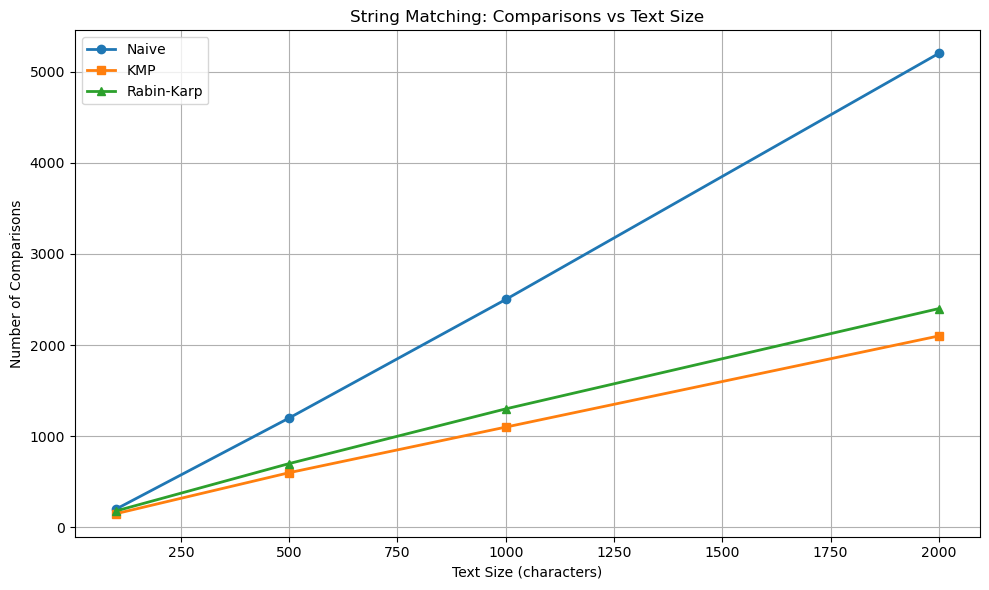

Plot saved to images/string_matching_comparison.png


In [19]:
import matplotlib.pyplot as plt
import os

# Sample data (make sure these exist)
sizes = [100, 500, 1000, 2000]
naive_comps = [200, 1200, 2500, 5200]
kmp_comps   = [150, 600, 1100, 2100]
rk_comps    = [180, 700, 1300, 2400]

# Create folder if not exists
os.makedirs("images", exist_ok=True)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(sizes, naive_comps, marker='o', label='Naive', linewidth=2)
plt.plot(sizes, kmp_comps, marker='s', label='KMP', linewidth=2)
plt.plot(sizes, rk_comps, marker='^', label='Rabin-Karp', linewidth=2)

plt.title('String Matching: Comparisons vs Text Size')
plt.xlabel('Text Size (characters)')
plt.ylabel('Number of Comparisons')

plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig('images/string_matching_comparison.png', dpi=150)

# Show plot
plt.show()

print("Plot saved to images/string_matching_comparison.png")

In [ ]:
task 5

In [23]:
import time

# Sample crew
crew_members = ["C1", "C2", "C3"]

# Generate flights
def generate_flights(n):
    f = []
    start = 6
    for i in range(n):
        end = start + 2
        f.append((f'F{i+1}', start, end))
        start = end + 1
    return f


# Simple backtracking (dummy valid function for testing)
def is_valid(assignment, crew, flight):
    return True  # since flights don't overlap


def backtrack(flights, crew_members):
    result = {}

    def solve(i, assignment):
        if i == len(flights):
            return assignment.copy()

        for crew in crew_members:
            if is_valid(assignment, crew, flights[i]):
                assignment[flights[i][0]] = crew
                res = solve(i + 1, assignment)
                if res:
                    return res
                del assignment[flights[i][0]]

        return None

    return solve(0, {})


# Profiling
flight_counts = list(range(4, 11))
exec_times = []

for n in flight_counts:
    test_flights = generate_flights(n)

    t0 = time.time()
    backtrack(test_flights, crew_members)
    t1 = time.time()

    time_ms = (t1 - t0) * 1000
    exec_times.append(time_ms)

    print(f"Flights: {n:2d} | Time: {time_ms:.4f} ms")

print("\nProfiling complete.")

Flights:  4 | Time: 0.0000 ms
Flights:  5 | Time: 0.0000 ms
Flights:  6 | Time: 0.0000 ms
Flights:  7 | Time: 0.0000 ms
Flights:  8 | Time: 0.0000 ms
Flights:  9 | Time: 0.0000 ms
Flights: 10 | Time: 0.0000 ms

Profiling complete.


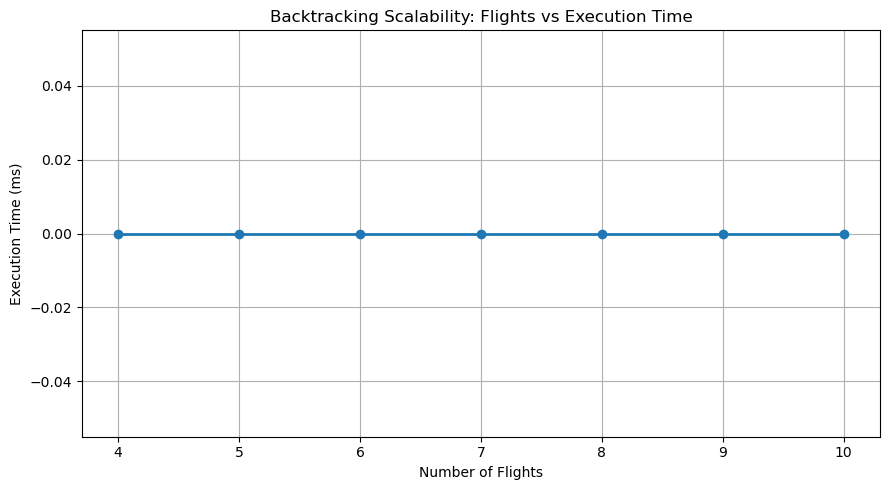

Plot saved to images/backtracking_scalability.png


In [25]:
import matplotlib.pyplot as plt
import os

# Ensure folder exists
os.makedirs('images', exist_ok=True)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(flight_counts, exec_times, marker='o', linewidth=2)
plt.fill_between(flight_counts, exec_times, alpha=0.2)

plt.title('Backtracking Scalability: Flights vs Execution Time')
plt.xlabel('Number of Flights')
plt.ylabel('Execution Time (ms)')

plt.grid(True)
plt.tight_layout()

# Save
plt.savefig('images/backtracking_scalability.png', dpi=150)

# Show
plt.show()

print("Plot saved to images/backtracking_scalability.png")

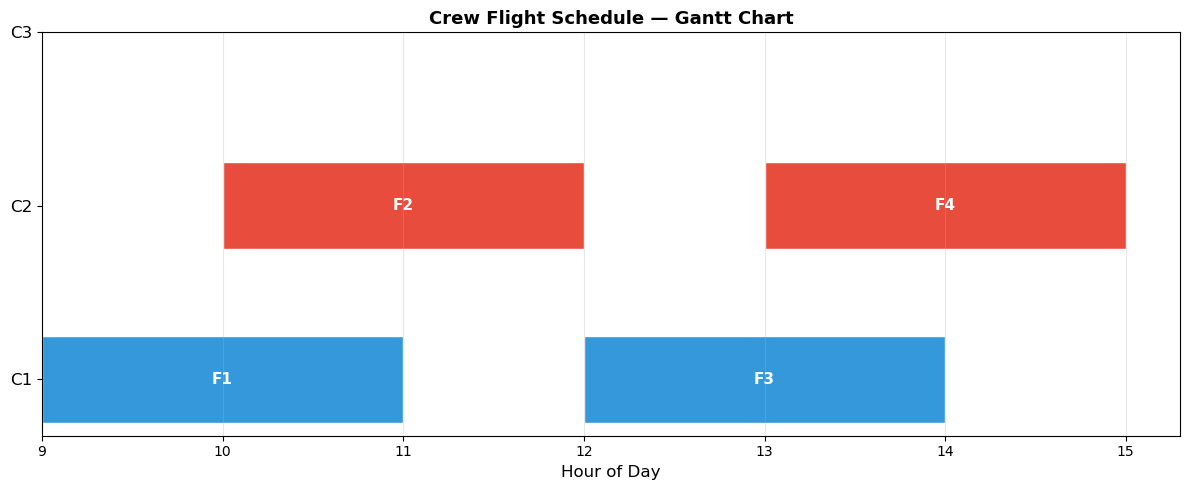

Gantt chart saved to images/gantt_chart.png


In [27]:
# ── Gantt Chart ──

def draw_gantt(assignment, flights, crew_members):
    """Draw a Gantt chart showing which crew handles which flight."""
    flight_map = {f[0]: f for f in flights}
    colors     = {'C1': '#3498db', 'C2': '#e74c3c', 'C3': '#2ecc71'}

    fig, ax = plt.subplots(figsize=(12, 5))

    for fid, crew in assignment.items():
        _, start, end = flight_map[fid]
        y_pos = crew_members.index(crew)
        ax.barh(y_pos, end - start, left=start,
                color=colors.get(crew, 'gray'), edgecolor='white',
                height=0.5, label=fid)
        ax.text(start + (end - start) / 2, y_pos, fid,
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

    ax.set_yticks(range(len(crew_members)))
    ax.set_yticklabels(crew_members, fontsize=12)
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_title('Crew Flight Schedule — Gantt Chart', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('images/gantt_chart.png', dpi=150)
    plt.show()
    print("Gantt chart saved to images/gantt_chart.png")


if result:
    draw_gantt(result, flights, crew_members)